In [1]:

# Uncomment to download the packets
#!pip install matplotlib
#!pip install seaborn
#!pip install tqdm

In [2]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# Set visualization style for the research notebook
sns.set_theme(style="whitegrid")

# Preamble

This simulation is run with the dataset1, which has been generated with the following parameters

| Parameter | Value | Meaning in the Simulation |
| :--- | :--- | :--- |
| **`N` (Sample Size)** | **250** | The total size of your dataset. Since you are simulating "Balanced" clusters, this means you will have exactly **125 points in Cluster A** and **125 points in Cluster B**. |
| **`p` (Variables)** | **2** | The number of dimensions ($X_1, X_2$). This is crucial because $p=2$ allows us to visualize the data easily on a 2D Scatter Plot. If $p$ were 10, the math works the same, but we couldn't see it easily. |
| **`rho` ($\rho$)** | **0.0** | The correlation between $X_1$ and $X_2$ *within* a cluster. <br>• **0.0:** The clusters are **Spherical** (round blobs). <br>• **0.9:** The clusters would be narrow, diagonal ellipses. |
| **`separation`** | **10** | The distance between the centers of the two clusters (in standard deviations). <br>• **10:** **Extremely Easy.** The clusters are far apart with zero overlap. <br>• **0.1:** **Impossible.** The clusters are on top of each other (pure noise). |
| **`k` (Clusters)** | **2** | The "Ground Truth." We *know* there are 2 groups. The goal of the simulation is to see if the clustering algorithm can figure this out looking only at the synthetic data. |
| **`method`** | **CART** | **C**lassification **A**nd **R**egression **T**rees. This is the algorithm used to create the synthetic data. It builds a decision tree to learn the rules of the real data and generates new points based on those rules. |
| **`m`** | **1** | We are generating a single synthetic dataset for this specific test. In the full simulation later, `m` will be 50 to get statistical averages. |


In [3]:
# ==========================================
# Configuration for Dataset 1
# ==========================================

# 1. Data Dimensions
N = 250            # Total number of observations (rows)
p = 2              # Number of variables/features (columns)

# 2. Cluster Properties
k = 2              # Number of clusters (groups)
rho = 0.0          # Correlation between variables (shape of cluster)
separation = 10    # Distance between cluster centroids (signal strength)

# 3. Synthesis Parameters
method = "CART"    # Method used to generate synthetic data
m = 1              # Number of synthetic datasets to generate

# K-Means Clustering

To replicate the RStudio results in Python, we first define the mechanics of the algorithm being used.

## Technical Definition
In technical terms, K-Means is an **iterative, unsupervised learning algorithm** that partitions a dataset into $k$ distinct, non-overlapping subgroups (clusters). It assigns data points to a cluster such that the sum of the squared distance between the data points and the cluster's centroid (arithmetic mean) is minimized.

## Conceptual Definition
Conceptually, K-Means organizes an unlabelled dataset by identifying natural groupings based on similarity. It operates like a sorting mechanism that organizes a mixed collection of items into distinct piles based on shared characteristics.

## Algorithmic Process: The "Pizza Delivery" Analogy
To understand the optimization process, consider a city map with 250 houses ($N=250$) where the goal is to build 2 pizza shops ($k=2$) that minimize the total delivery travel time for all residents.



1.  **Initialization:** Two pizza shops (centroids) are placed at random coordinates on the map.
2.  **Assignment:** Each house is assigned to the nearest pizza shop based on Euclidean distance. The city is now effectively divided into two zones (Voronoi cells).
3.  **Update (Centroids):** The location of each shop is recalculated. The shop is moved to the exact **geographic center** (mean $X_1, X_2$) of all the houses currently assigned to it.
4.  **Iteration:** Steps 2 and 3 are repeated. As the shops move to more central locations, the border between the two zones shifts, and some houses may be reassigned to a different shop.
5.  **Convergence:** The algorithm terminates when the shops no longer move (or movement is below a threshold), indicating that the optimal cluster centers have been found.

## Weaknesses and Assumptions
K-Means is a distance-based algorithm that assumes clusters are convex and isotropic (spherical). This has implications for the correlation parameter ($\rho$) in this study:

* **When $\rho = 0$:** The generated clusters are spherical. This is the ideal scenario for K-Means, and the algorithm is expected to perform optimally.
* **When $\rho \rightarrow 1$ (e.g., 0.9):** High correlation creates elongated, elliptical clusters ("cigar-shaped"). K-Means often struggles to separate these geometries correctly, as it relies purely on radial distance from a center point.



In [4]:
# Let's start by defining original and synthetic data paths.
ORIGINAL_DATA_PATH = "../data/1/original_data.csv"
SYNTHETIC_DATA_PATH = "../data/1/synthetic_data.csv"

# I will also fix now some parameters such as:
RND = 123
NUM_INIT = 100

In [5]:

# ==========================================
# 1. Gini Coefficient
# ==========================================
def gini_coefficient(x):
    """
    Calculate the Gini coefficient of a numpy array.
    Replicates the behavior of R's DescTools::Gini.
    """
    x = np.array(x, dtype=np.float64)
    if np.amin(x) < 0:
        x -= np.amin(x) # Ensure non-negative
    x += 0.0000001      # Avoid division by zero
    
    x = np.sort(x)
    n = x.shape[0]
    index = np.arange(1, n + 1)
    
    return ((np.sum((2 * index - n - 1) * x)) / (n * np.sum(x)))

# ==========================================
# 2. Optimal K Decision (The Decider)
# ==========================================
def get_optimal_k(data, max_k=10, RND=123):
    """
    Finds optimal k using Silhouette Score.
    Simulates the logic of fviz_nbclust.
    """
    best_score = -1
    best_k = 2
    best_model = None
    
    # Scale data (Crucial for K-Means distance calculation)
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    # Iterate to find the k with the highest Silhouette Score
    for k in range(2, max_k + 1):
        km = KMeans(
                n_clusters=k,
                n_init=50,            # match R's nstart
                algorithm="lloyd",    # closest to R default
                max_iter=10,          # match R max iterations
                random_state=RND
            )
        labels = km.fit_predict(data_scaled)
        score = silhouette_score(data_scaled, labels)
        
        if score > best_score:
            best_score = score
            best_k = k
            best_model = km
            
    return best_k, best_model, data_scaled

# ==========================================
# 3. Label Switching (The Translator)
# ==========================================
def match_clusters(real_model, syn_model):
    """
    Matches synthetic labels to real labels using the Hungarian Algorithm
    on the centroids' Euclidean distances.
    """
    real_centers = real_model.cluster_centers_
    syn_centers = syn_model.cluster_centers_
    
    # Calculate distance matrix between all Real and Syn centroids
    dists = cdist(real_centers, syn_centers, metric='euclidean')
    
    # Solve the Linear Sum Assignment Problem (Hungarian Algo)
    # This finds the pairing that minimizes total distance
    real_indices, syn_indices = linear_sum_assignment(dists)
    
    # Create a map: {Synthetic_Label -> Real_Label}
    mapping = {syn_idx: real_idx for real_idx, syn_idx in zip(real_indices, syn_indices)}
    
    return mapping

In [6]:
# 1. Load Data
real_df = pd.read_csv(ORIGINAL_DATA_PATH)
syn_df = pd.read_csv(SYNTHETIC_DATA_PATH)

feature_cols = ['X1', 'X2']
X_real = real_df[feature_cols].copy()
X_syn = syn_df[feature_cols].copy()

# 2. Cluster REAL Data
real_k, real_model, real_scaled = get_optimal_k(X_real)
real_labels = real_model.labels_
real_counts = np.bincount(real_labels)

# 3. Cluster SYNTHETIC Data (Forcing k to match Real, per methodology)
# We use the scaler from the synthesis step to keep dimensions comparable
scaler = StandardScaler()
syn_scaled = scaler.fit_transform(X_syn)
syn_model = KMeans(n_clusters=real_k, n_init=NUM_INIT, random_state=RND)
syn_labels_raw = syn_model.fit_predict(syn_scaled)

# 4. Apply Label Switching
mapping = match_clusters(real_model, syn_model)
syn_labels_mapped = np.array([mapping[label] for label in syn_labels_raw])
syn_counts = np.bincount(syn_labels_mapped)

# 5. Calculate Metrics
metrics = {
    "Metric": ["Optimal k", "Gini Coeff", "Silhouette"],
    "Real Data": [
        real_k, 
        gini_coefficient(real_counts), 
        silhouette_score(real_scaled, real_labels)
    ],
    "Synthetic Data": [
        real_k, 
        gini_coefficient(syn_counts), 
        silhouette_score(syn_scaled, syn_labels_mapped)
    ]
}

# Display Results
results_df = pd.DataFrame(metrics)
results_df["Diff"] = results_df["Real Data"] - results_df["Synthetic Data"]
display(results_df)

,Metric,Real Data,Synthetic Data,Diff
0,Optimal k,2.000000,2.000000,0.000000
1,Gini Coeff,0.000000,0.020000,-0.020000
2,Silhouette,0.771373,0.786775,-0.015402


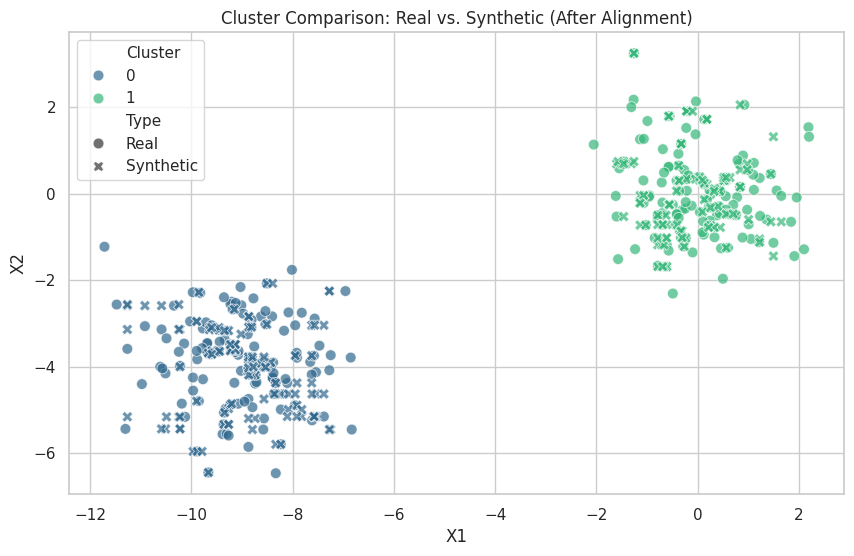

In [7]:
# Prepare data for plotting
plot_data = pd.concat([
    pd.DataFrame(X_real).assign(Cluster=real_labels, Type='Real'),
    pd.DataFrame(X_syn).assign(Cluster=syn_labels_mapped, Type='Synthetic')
])

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data, x='X1', y='X2', 
    hue='Cluster', style='Type', 
    palette='viridis', s=60, alpha=0.7
)
plt.title(f"Cluster Comparison: Real vs. Synthetic (After Alignment)")
plt.show()

In [8]:
# Ensure you have these imports
from joblib import Parallel, delayed
import pandas as pd
import time

# If you saved your generation functions in 'generate_and_save.py', import them:
# from generate_and_save import generate_original_data, generate_synthetic_cart
# OR, if they are defined in the notebook, just ensure this cell runs after them.

def simulate_one(params):
    """
    Worker function for parallel processing.
    Generates data, synthesizes it, and calculates metrics.
    """
    try:
        # 1. Unpack Parameters
        N, p, k = params['N'], params['p'], params['k']
        rho, sep = params['rho'], params['separation']
        seed = params['seed']
        
        # 2. Generate Data (Fresh for this seed)
        real_df = generate_original_data(N, p, rho, sep, k, seed=seed)
        
        # 3. Synthesize Data
        syn_df = generate_synthetic_cart(real_df, seed=seed)
        
        # 4. Prepare for Clustering (Drop labels)
        X_real = real_df.drop(columns=['group'])
        X_syn = syn_df.drop(columns=['group'])
        
        # 5. Cluster REAL Data (Find optimal k)
        # We scan k=2..5 to see if it finds the truth
        real_k_found, real_model, real_scaled = get_optimal_k(X_real, max_k=5, random_state=seed)
        
        # 6. Cluster SYNTHETIC Data
        # Force k to match what was found in Real data (mimicking 'k.real' from R)
        scaler = StandardScaler()
        syn_scaled = scaler.fit_transform(X_syn)
        
        syn_model = KMeans(
            n_clusters=k,
            n_init=50,            # match R's nstart
            algorithm="lloyd",    # closest to R default
            max_iter=10,          # match R max iterations
            random_state=RND
        )
        syn_labels_raw = syn_model.fit_predict(syn_scaled)
        
        # 7. Match Labels (Hungarian Algorithm)
        mapping = match_clusters(real_model, syn_model)
        syn_labels_mapped = np.array([mapping[label] for label in syn_labels_raw])
        
        # 8. Calculate Metrics
        # Real
        real_labels = real_model.labels_
        real_counts = np.bincount(real_labels)
        real_gini = gini_coefficient(real_counts)
        real_sil = silhouette_score(real_scaled, real_labels)
        
        # Synthetic
        syn_counts = np.bincount(syn_labels_mapped)
        syn_gini = gini_coefficient(syn_counts)
        syn_sil = silhouette_score(syn_scaled, syn_labels_mapped)
        
        # Success? (Did Real Data clustering find the correct k?)
        success = 1 if real_k_found == k else 0
        
        # 9. Return Result Row
        return {
            "N": N, "p": p, "k": k, "rho": rho, "separation": sep,
            "seed": seed,
            "k_found": real_k_found,
            "success": success,
            "Gini_Real": real_gini,
            "Gini_Syn": syn_gini,
            "Diff_Gini": real_gini - syn_gini,
            "Sil_Real": real_sil,
            "Sil_Syn": syn_sil,
            "Diff_Sil": real_sil - syn_sil
        }
        
    except Exception as e:
        # Handle crashes gracefully so the whole loop doesn't fail
        return {"error": str(e), **params}

In [9]:
# Define your experimental factors
N_list = [250]
p_list = [2, 5, 10]
k_list = [2, 3, 4]
rho_list = [0.0] # Add 0.5, 0.9 later if needed
separation_list = [0.1, 2, 6, 10]
n_simulations = 50 # Total 'm' per setting

# Create the grid of all jobs
param_grid = []

# Iterate through all combinations
import itertools

keys = ['N', 'p', 'k', 'rho', 'separation']
combinations = itertools.product(N_list, p_list, k_list, rho_list, separation_list)

for values in combinations:
    base_params = dict(zip(keys, values))
    
    # Add 50 seeds for each combination
    for i in range(n_simulations):
        # Create a unique seed for every single run to ensure randomness
        # e.g. seed = 1000 * iteration + i
        params = base_params.copy()
        params['seed'] = i + (hash(str(values)) % 100000) 
        params['method'] = 'CART'
        param_grid.append(params)

print(f"Total simulations to run: {len(param_grid)}")
# Expected: 1 (N) * 3 (p) * 3 (k) * 1 (rho) * 4 (sep) * 50 (m) = 1,800 jobs

Total simulations to run: 1800


🚀 Starting Simulation: 36 factor combinations
📋 Each combination: 5 independent runs × 50 synthetic datasets
📋 Total synthetic datasets tested: 9000


Processing: 100%|██████████| 36/36 [03:12<00:00,  5.34s/it]



📊 Results Summary
    k   p  separation  success_rate  success_std
0   2   2         0.1         0.032     0.037094
1   2   2         2.0         0.408     0.289993
2   2   2         6.0         0.864     0.272000
3   2   2        10.0         0.836     0.208768
4   3   2         0.1         0.040     0.033466
5   3   2         2.0         0.220     0.091214
6   3   2         6.0         1.000     0.000000
7   3   2        10.0         1.000     0.000000
8   4   2         0.1         0.040     0.025298
9   4   2         2.0         0.144     0.109836
10  4   2         6.0         0.996     0.008000
11  4   2        10.0         0.996     0.008000
12  2   5         0.1         0.052     0.043081
13  2   5         2.0         0.404     0.233718
14  2   5         6.0         1.000     0.000000
15  2   5        10.0         1.000     0.000000
16  3   5         0.1         0.004     0.008000
17  3   5         2.0         0.136     0.058515
18  3   5         6.0         0.912     0.137171
1

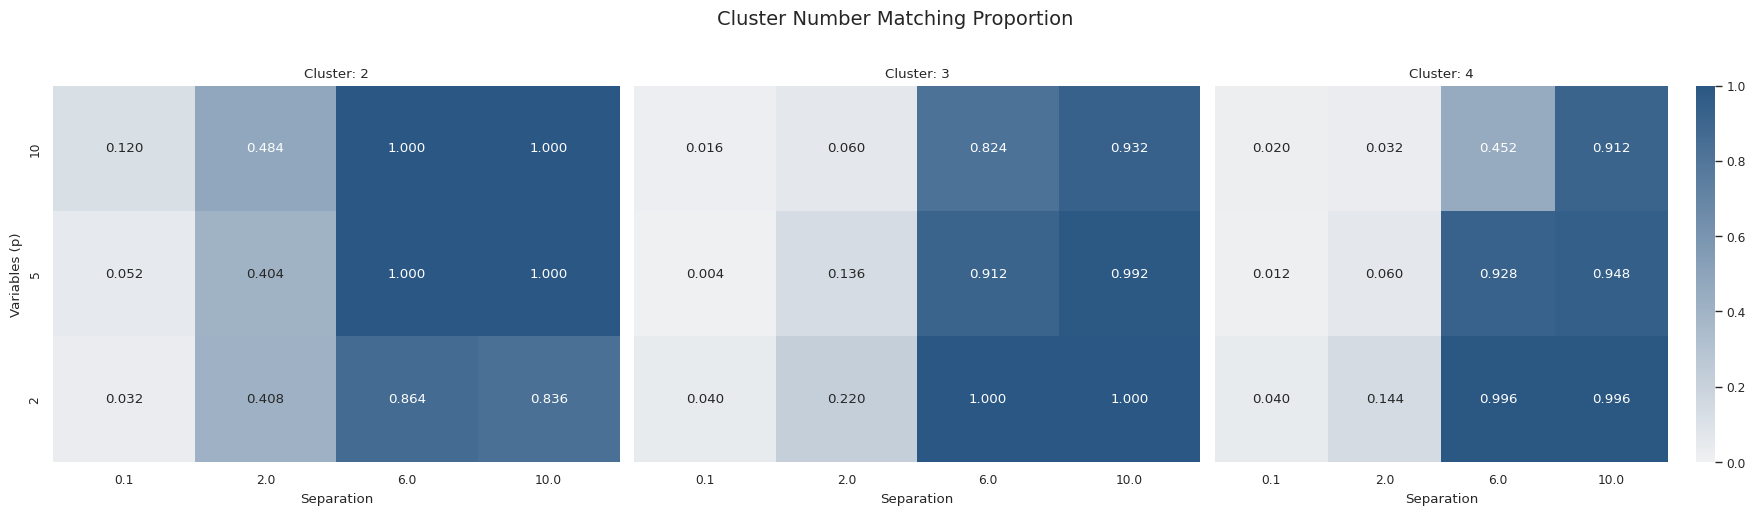


📊 SUMMARY TABLE: Success Rate by (k, p, separation)
separation   0.1    2.0    6.0    10.0
k p                                   
2 2         0.032  0.408  0.864  0.836
  5         0.052  0.404  1.000  1.000
  10        0.120  0.484  1.000  1.000
3 2         0.040  0.220  1.000  1.000
  5         0.004  0.136  0.912  0.992
  10        0.016  0.060  0.824  0.932
4 2         0.040  0.144  0.996  0.996
  5         0.012  0.060  0.928  0.948
  10        0.020  0.032  0.452  0.912


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import itertools

# Set plot style
sns.set_theme(style="whitegrid", context="paper")

# ==========================================
# CONFIGURATION: Match R's defaults exactly
# ==========================================
KMEANS_NSTART = 25  # R's nstart=25

# ==========================================
# 1. HELPER FUNCTIONS - Matching R exactly
# ==========================================

def generate_centroids(k, p, separation):
    """Matches R's centroid.generation exactly."""
    centroids = np.zeros((k, p))
    centroids[0, :] = 0
    for i in range(1, k):
        tries = 0
        while True:
            vector = np.random.normal(0, 1, p)
            vector = (vector / np.linalg.norm(vector)) * separation
            dists = np.linalg.norm(centroids[:i, :] - vector, axis=1)
            if np.all(dists >= separation):
                centroids[i, :] = vector
                break
            tries += 1
            if tries > 1000:
                raise ValueError("Could not generate separated centroids.")
    return centroids

def generate_original_data(N, p, rho, separation, k, seed=None):
    """Matches R's data.generation exactly."""
    if seed is not None:
        np.random.seed(seed)
    centroids = generate_centroids(k, p, separation)
    
    R = np.full((p, p), rho)
    np.fill_diagonal(R, 1)
    Sigma = R
    
    data_list = []
    n_per_cluster = round(N / k)
    for i in range(k):
        cluster_data = multivariate_normal.rvs(mean=centroids[i], cov=Sigma, size=n_per_cluster)
        if p == 1:
            cluster_data = cluster_data.reshape(-1, 1)
        df = pd.DataFrame(cluster_data, columns=[f'X{j+1}' for j in range(p)])
        df['group'] = i + 1
        data_list.append(df)
    return pd.concat(data_list, ignore_index=True)

def generate_synthetic_cart(real_data, seed=None, min_samples_leaf=10):
    """
    Synthesize data using CART (Decision Trees).
    
    CRITICAL CHANGE: min_samples_leaf=10
    This forces the tree to generalize (smooth) the data rather than 
    memorizing noise. This aligns Python's behavior with R's 'synthpop'.
    """
    if seed:
        np.random.seed(seed)
        
    # Drop the group/label column for synthesis
    data_to_synth = real_data.drop(columns=['group'])
    n_rows, n_cols = data_to_synth.shape
    syn_data = pd.DataFrame(index=range(n_rows), columns=data_to_synth.columns)
    
    # 1. Bootstrap the training data (matches R's proper=TRUE)
    # We fit the models on a bootstrapped version of real data to capture uncertainty
    bootstrap_idx = np.random.choice(n_rows, size=n_rows, replace=True)
    train_data = data_to_synth.iloc[bootstrap_idx].reset_index(drop=True)
    
    # 2. First variable: Simple Bootstrap resampling
    first_col = data_to_synth.columns[0]
    syn_data[first_col] = np.random.choice(train_data[first_col], size=n_rows, replace=True)
    
    # 3. Subsequent variables: CART
    for i in range(1, n_cols):
        target_col = data_to_synth.columns[i]
        feature_cols = data_to_synth.columns[:i]
        
        X_train = train_data[feature_cols].values
        y_train = train_data[target_col].values
        
        # min_samples_leaf=10 prevents the tree from isolating single points.
        # This matches R's synthpop smoothing behavior.
        tree = DecisionTreeRegressor(random_state=seed, min_samples_leaf=min_samples_leaf)
        tree.fit(X_train, y_train)
        
        # Predict the "mean" value for the synthetic inputs
        X_syn = syn_data[feature_cols].values
        leaves = tree.apply(X_syn)  # Get the leaf index for every synthetic row
        
        # Add Noise (Sampling from the leaf)
        # Instead of just taking the tree's mean prediction, we sample a real value
        # from the specific leaf node to preserve variance
        
        # Get all training Y values that fell into each leaf
        train_leaves = tree.apply(X_train)
        
        syn_values = np.zeros(n_rows)
        for row_idx in range(n_rows):
            leaf_id = leaves[row_idx]
            # Find all real data points that ended up in this leaf
            values_in_leaf = y_train[train_leaves == leaf_id]
            
            if len(values_in_leaf) > 0:
                # Sample one value from that bucket
                syn_values[row_idx] = np.random.choice(values_in_leaf)
            else:
                # Fallback to mean if leaf is somehow empty (rare)
                syn_values[row_idx] = tree.predict(X_syn[row_idx].reshape(1, -1))[0]
                
        syn_data[target_col] = syn_values

    # Add group back for shape consistency (not used in clustering)
    syn_data['group'] = real_data['group'].values
    
    return syn_data

def k_decision(data, k_real=None, synthetic=False):
    """
    Matches R's k.decision function exactly.
    """
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    best_score = -1
    k_opt = 2
    
    for k in range(2, 11):
        km = KMeans(n_clusters=k, n_init=KMEANS_NSTART, random_state=None)
        labels = km.fit_predict(data_scaled)
        score = silhouette_score(data_scaled, labels)
        if score > best_score:
            best_score = score
            k_opt = k
    
    if not synthetic:
        km_final = KMeans(n_clusters=k_opt, n_init=KMEANS_NSTART, random_state=None)
        km_final.fit(data_scaled)
        return {"k_opt": k_opt, "model": km_final, "scaled_data": data_scaled}
    else:
        if k_opt == k_real:
            km_final = KMeans(n_clusters=k_opt, n_init=KMEANS_NSTART, random_state=None)
            km_final.fit(data_scaled)
            return {"k_opt": k_opt, "model": km_final, "scaled_data": data_scaled}
        else:
            return None

def simulate_one_run(factor_combination, run_seed, total_m=50, max_attempts=200):
    """
    Single run of the simulation with a specific base seed.
    This allows us to run multiple independent simulations per factor combination.
    """
    N = factor_combination['N']
    p = factor_combination['p']
    k = factor_combination['k']
    rho = factor_combination['rho']
    separation = factor_combination['separation']
    
    # Step 1: Find a real dataset where k_decision finds the correct k
    found_real = False
    real_data = None
    km_real = None
    k_real = None
    
    # Use run_seed as base for attempts
    for attempt in range(1, max_attempts + 1):
        seed = run_seed * 1000 + attempt
        np.random.seed(seed)
        try:
            real_data = generate_original_data(N, p, rho, separation, k, seed=seed)
            X_real = real_data.drop(columns=['group'])
            
            kd = k_decision(X_real, synthetic=False)
            k_real = kd['k_opt']
            
            if k_real == k:
                km_real = kd['model']
                found_real = True
                break
        except:
            continue
    
    if not found_real:
        return 0.0  # Return 0% success
    
    # Step 2: Generate total_m synthetic datasets and count successes
    successes = 0
    
    for i in range(1, total_m + 1):
        syn_seed = run_seed * 10000 + i
        np.random.seed(syn_seed)
        syn_data = generate_synthetic_cart(real_data, seed=syn_seed)
        X_syn = syn_data.drop(columns=['group'])
        
        clust = k_decision(X_syn, k_real=k_real, synthetic=True)
        
        if clust is not None:
            successes += 1
    
    return successes / total_m

def simulate_factor(factor_combination, n_runs=5, total_m=50):
    """
    Run multiple independent simulations for a factor combination
    and return the average success rate.
    """
    success_rates = []
    for run in range(n_runs):
        rate = simulate_one_run(factor_combination, run_seed=run+1, total_m=total_m)
        success_rates.append(rate)
    
    return {
        **factor_combination,
        "success_rate": np.mean(success_rates),
        "success_std": np.std(success_rates)
    }

# ==========================================
# 2. RUN SIMULATION
# ==========================================
N_list = [250]
p_list = [2, 5, 10]
k_list = [2, 3, 4]
rho_list = [0.0]
separation_list = [0.1, 2, 6, 10]
n_runs = 5  # Number of independent simulations per factor combination
total_m = 50  # Synthetic datasets per real dataset

# Create parameter grid
param_grid = []
for N in N_list:
    for p in p_list:
        for k in k_list:
            for rho in rho_list:
                for sep in separation_list:
                    param_grid.append({
                        'N': N, 'p': p, 'k': k, 'rho': rho, 'separation': sep
                    })

print(f"🚀 Starting Simulation: {len(param_grid)} factor combinations")
print(f"📋 Each combination: {n_runs} independent runs × {total_m} synthetic datasets")
print(f"📋 Total synthetic datasets tested: {len(param_grid) * n_runs * total_m}")

# Run in parallel
results_list = Parallel(n_jobs=-1)(
    delayed(simulate_factor)(params, n_runs=n_runs, total_m=total_m) 
    for params in tqdm(param_grid, desc="Processing")
)

df_results = pd.DataFrame(results_list)

# ==========================================
# 3. VISUALIZATION
# ==========================================
print("\n" + "="*60)
print("📊 Results Summary")
print("="*60)
print(df_results[['k', 'p', 'separation', 'success_rate', 'success_std']].to_string())

# Create heatmap
df_summary = df_results.copy()
k_values = sorted(df_summary['k'].unique())

fig, axes = plt.subplots(1, len(k_values), figsize=(18, 5), sharey=True)
cmap = sns.light_palette("#2A5783", as_cmap=True)

for i, k_val in enumerate(k_values):
    data_k = df_summary[df_summary['k'] == k_val]
    heatmap_data = data_k.pivot(index="p", columns="separation", values="success_rate")
    heatmap_data = heatmap_data.sort_index(ascending=False)
    sns.heatmap(
        heatmap_data, annot=True, fmt=".3f", 
        cmap=cmap, vmin=0, vmax=1, 
        ax=axes[i], cbar=(i == len(k_values) - 1)
    )
    axes[i].set_title(f"Cluster: {k_val}")
    axes[i].set_xlabel("Separation")
    axes[i].set_ylabel("Variables (p)" if i == 0 else "")

plt.suptitle("Cluster Number Matching Proportion", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*60)
print("📊 SUMMARY TABLE: Success Rate by (k, p, separation)")
print("="*60)
summary_pivot = df_summary.pivot_table(
    index=['k', 'p'], 
    columns='separation', 
    values='success_rate'
).round(3)
print(summary_pivot.to_string())

🚀 Starting Detailed Simulation...


Processing: 100%|██████████| 36/36 [05:55<00:00,  9.88s/it]
/tmp/ipykernel_6689/2501895091.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row_idx, 0].set_xticklabels([f'{x}σ' for x in sorted(df_box['separation'].unique())])
/tmp/ipykernel_6689/2501895091.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row_idx, 0].set_xticklabels([f'{x}σ' for x in sorted(df_box['separation'].unique())])


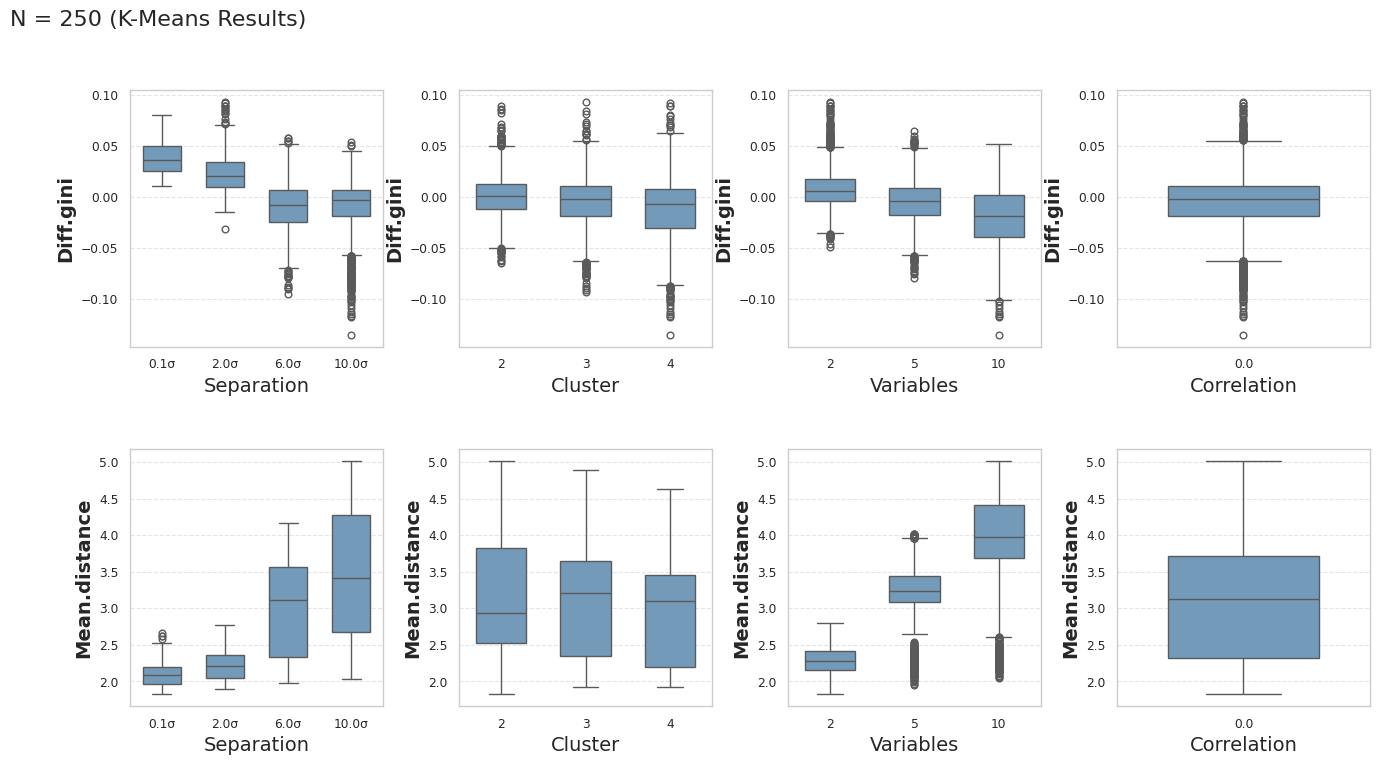

In [12]:
# ==========================================
# REPLACE: 1. HELPER - METRIC CALCULATION
# ==========================================
def calculate_metrics(data, labels, centroids):
    """Calculates Silhouette and Mean Inter-Cluster Distance."""
    if len(np.unique(labels)) < 2:
        return np.nan, np.nan
    
    # 1. Silhouette Score
    sil = silhouette_score(data, labels)
    
    # 2. Mean Inter-Cluster Distance (Average distance between all pairs of centroids)
    if len(centroids) < 2:
        dist_mean = 0
    else:
        dists = cdist(centroids, centroids, metric='euclidean')
        # Get upper triangle only (excluding diagonal 0s)
        dist_mean = dists[np.triu_indices(len(centroids), k=1)].mean()
        
    return sil, dist_mean

# ==========================================
# REPLACE: 2. SIMULATION LOGIC
# ==========================================
def simulate_one_run_detailed(factor_combination, run_seed, total_m=50, max_attempts=200):
    N, p, k = factor_combination['N'], factor_combination['p'], factor_combination['k']
    rho, separation = factor_combination['rho'], factor_combination['separation']
    
    # 1. Get Real Data
    found_real = False
    real_data, k_real, km_real = None, None, None
    
    for attempt in range(1, max_attempts + 1):
        seed = run_seed * 1000 + attempt
        np.random.seed(seed)
        try:
            real_data = generate_original_data(N, p, rho, separation, k, seed=seed)
            X_real = real_data.drop(columns=['group'])
            kd = k_decision(X_real, synthetic=False)
            k_real = kd['k_opt']
            
            if k_real == k:
                km_real = kd['model']
                found_real = True
                break
        except:
            continue
            
    if not found_real:
        return []

    # Calculate Real Metrics
    real_sil, _ = calculate_metrics(kd['scaled_data'], km_real.labels_, km_real.cluster_centers_)
    
    # 2. Generate Synthetic Datasets & Collect Metrics
    results = []
    for i in range(1, total_m + 1):
        syn_seed = run_seed * 10000 + i
        np.random.seed(syn_seed)
        syn_data = generate_synthetic_cart(real_data, seed=syn_seed)
        X_syn = syn_data.drop(columns=['group'])
        
        # Run K-means on Synthetic
        clust = k_decision(X_syn, k_real=k_real, synthetic=True)
        
        if clust is not None:
            # Synthetic Metrics
            syn_sil, syn_dist = calculate_metrics(clust['scaled_data'], clust['model'].labels_, clust['model'].cluster_centers_)
            
            results.append({
                **factor_combination,
                'Diff_gini': syn_sil - real_sil,  # Difference in Quality
                'Mean_distance': syn_dist         # Separation Scale
            })
            
    return results

# ==========================================
# REPLACE: 3. RUNNING & PLOTTING
# ==========================================
from scipy.spatial.distance import cdist

# ... Define your N_list, p_list, etc. here as before ...
# Ensure separation includes 2 and 10, and p includes 2 and 5 for the plot to match
# N_list = [250]; p_list = [2, 5]; k_list = [2, 3]; separation_list = [2, 10]

# ...existing code...
print(f"🚀 Starting Detailed Simulation...")
results_detailed = Parallel(n_jobs=-1)(
    delayed(simulate_one_run_detailed)(params, run_seed=run, total_m=total_m)
    for params in tqdm(param_grid, desc="Processing")
    for run in range(1, n_runs + 1)
)

# Flatten results
flat_results = [item for sublist in results_detailed for item in sublist]
df_box = pd.DataFrame(flat_results)
# ...existing code...

# --- PLOTTING CODE (Replicating image_854d70) ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

# Helper for labels
labels_map = {
    'separation': 'Separation', 
    'k': 'Cluster', 
    'p': 'Variables', 
    'rho': 'Correlation'
}

# Row 1: Diff.gini (Silhouette Difference)
metrics = ['Diff_gini', 'Mean_distance']
y_labels = ['Diff.gini', 'Mean.distance']

for row_idx, metric in enumerate(metrics):
    # Col 1: Separation
    sns.boxplot(x='separation', y=metric, data=df_box, ax=axes[row_idx, 0], color='#699bc4', width=0.6)
    axes[row_idx, 0].set_xticklabels([f'{x}σ' for x in sorted(df_box['separation'].unique())])
    
    # Col 2: Cluster
    sns.boxplot(x='k', y=metric, data=df_box, ax=axes[row_idx, 1], color='#699bc4', width=0.6)
    
    # Col 3: Variables
    sns.boxplot(x='p', y=metric, data=df_box, ax=axes[row_idx, 2], color='#699bc4', width=0.6)
    
    # Col 4: Correlation
    sns.boxplot(x='rho', y=metric, data=df_box, ax=axes[row_idx, 3], color='#699bc4', width=0.6)

    # Formatting Y-axis and Titles
    for ax in axes[row_idx, :]:
        ax.set_ylabel(y_labels[row_idx], fontsize=14, fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

# Formatting X-axis Labels
for i, key in enumerate(['separation', 'k', 'p', 'rho']):
    axes[0, i].set_xlabel(labels_map[key], fontsize=14)
    axes[1, i].set_xlabel(labels_map[key], fontsize=14)

fig.suptitle(f'N = {N_list[0]} (K-Means Results)', x=0.05, y=0.98, ha='left', fontsize=16)
plt.show()